<img src="../Decorative-Elements/Section-04/ADL-S04-Image-04-e.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/03-LEAPFROG-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/05-MERCURIUS-Integrator.ipynb" target="_blank">Next</a>
</p>

In [1]:
# Janus (Leapfrog) Integrator - Important Use Case
# - Ideal for long-term orbital evolution studies with moderate accuracy.
# - Symplectic: preserves total energy over long simulations.
# - Best for N-body systems with uniform time steps, such as:
#     • Asteroid belts
#     • Star clusters
#     • Planetary systems without close encounters
# - Simple to implement in 1D, 2D, or 3D, making it widely used in both research and educational contexts.

In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# # Initialize simulation
sim = rebound.Simulation()
sim.units = ('AU','yr','Msun')        # Set units: Astronomical Units, years, solar masses
sim.integrator = "janus"              # Use Janus integrator (symplectic, suitable for N-body)
sim.dt = 0.001                         # Small timestep to accurately resolve moons

In [4]:
# Add Sun
sim.add(m=1.0)                        # Central star with 1 solar mass


# Add Planet (Jupiter)
planet_mass = 0.001                   # Mass in Msun (~Jupiter mass)
planet_a = 5.2                        # Semi-major axis in AU
sim.add(m=planet_mass, a=planet_a, e=0.0)  # Circular orbit
planet_index = 1                       # Index of planet in simulation
planet = sim.particles[planet_index]   # Reference to planet particle

# Add Moons around Jupiter
moon_data = [
    {"m":1e-6, "a":0.01, "e":0.0, "color":"orange", "label":"Moon 1"},
    {"m":0.5e-6, "a":0.015, "e":0.05, "color":"cyan", "label":"Moon 2"},
    {"m":0.8e-6, "a":0.02, "e":0.02, "color":"magenta", "label":"Moon 3"}
]

moons_indices = []                    # Store indices of moons in simulation
for moon in moon_data:
    # Add each moon with semi-major axis relative to Jupiter as primary
    sim.add(m=moon["m"], a=moon["a"], e=moon["e"], primary=planet)
    moons_indices.append(len(sim.particles)-1)

# Move entire system to center-of-mass frame for numerical stability
sim.move_to_com()

In [5]:
# Integration parameters
years = 2                             # Total simulation time in years
N_steps = int(years / sim.dt)         # Total number of integration steps

# Arrays to store positions, energies, angular momentum
planet_positions = np.zeros((N_steps,2))                       # Planet x,y positions
moon_positions_relative = [np.zeros((N_steps,2)) for _ in moons_indices]  # Moon positions relative to Jupiter
kinetic_energy = np.zeros(N_steps)
potential_energy = np.zeros(N_steps)
total_energy = np.zeros(N_steps)
angular_momentum = np.zeros(N_steps)

In [6]:
# Energy and angular momentum functions
def compute_energy(sim):
    """Compute kinetic and potential energy of the system"""
    KE = 0.0
    PE = 0.0
    N = len(sim.particles)
    for i in range(N):
        pi = sim.particles[i]
        KE += 0.5 * pi.m * (pi.vx**2 + pi.vy**2 + pi.vz**2)  # Kinetic energy
        for j in range(i+1, N):
            pj = sim.particles[j]
            dx = pi.x - pj.x
            dy = pi.y - pj.y
            dz = pi.z - pj.z
            r = np.sqrt(dx**2 + dy**2 + dz**2)
            PE -= pi.m * pj.m / r                               # Gravitational potential energy
    return KE, PE

In [7]:
def compute_angular_momentum(sim):
    # Compute magnitude of total angular momentum vector of the system
    Lx = Ly = Lz = 0.0
    for pi in sim.particles:
        # Compute cross product r x v for each particle
        Lx += pi.m * (pi.y*pi.vz - pi.z*pi.vy)
        Ly += pi.m * (pi.z*pi.vx - pi.x*pi.vz)
        Lz += pi.m * (pi.x*pi.vy - pi.y*pi.vx)
    return np.sqrt(Lx**2 + Ly**2 + Lz**2)

# Integration loop
for i in range(N_steps):
    sim.integrate(sim.t + sim.dt)           # Advance simulation by one timestep
    
    # Store planet position for plotting
    planet_positions[i] = [planet.x, planet.y]
    
    # Store moon positions relative to Jupiter
    for j, idx in enumerate(moons_indices):
        moon = sim.particles[idx]
        moon_positions_relative[j][i] = [moon.x - planet.x, moon.y - planet.y]
    
    # Compute energies and angular momentum at this step
    KE, PE = compute_energy(sim)
    kinetic_energy[i] = KE
    potential_energy[i] = PE
    total_energy[i] = KE + PE
    angular_momentum[i] = compute_angular_momentum(sim)

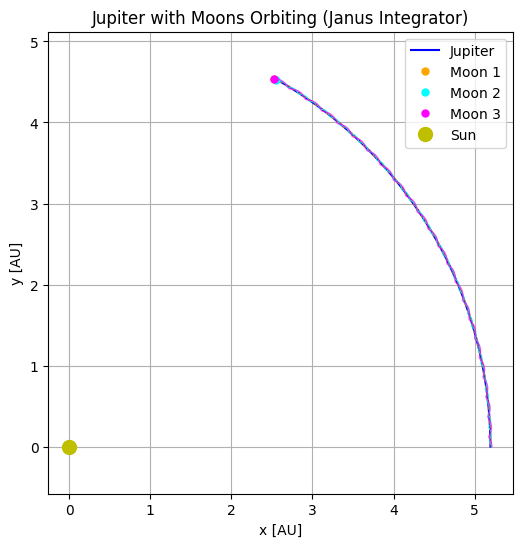

In [8]:
# Plot Jupiter orbiting Sun with moons
plt.figure(figsize=(6,6))
plt.plot(planet_positions[:,0], planet_positions[:,1], label='Jupiter', color='blue')
for j, moon in enumerate(moon_data):
    # Moon orbit paths relative to Sun
    plt.plot(planet_positions[:,0] + moon_positions_relative[j][:,0],
             planet_positions[:,1] + moon_positions_relative[j][:,1],
             color=moon["color"], lw=0.8, alpha=0.7)
    # Final position marker for moon
    plt.plot(planet_positions[-1,0] + moon_positions_relative[j][-1,0],
             planet_positions[-1,1] + moon_positions_relative[j][-1,1],
             'o', color=moon["color"], markersize=5, label=moon["label"])

# Sun at origin
plt.plot(0,0,'yo', markersize=10, label='Sun')
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Jupiter with Moons Orbiting (Janus Integrator)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

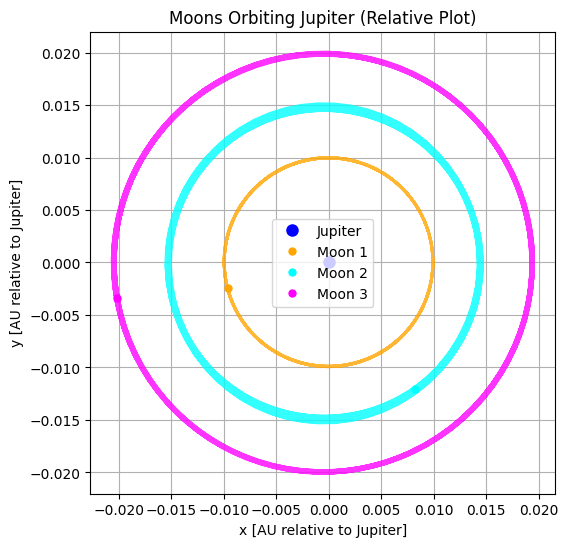

In [9]:
# Plot moons relative to Jupiter
plt.figure(figsize=(6,6))
plt.plot(0,0,'bo', markersize=8, label='Jupiter')  # Jupiter at origin
for j, moon in enumerate(moon_data):
    # Moon orbit path relative to Jupiter
    plt.plot(moon_positions_relative[j][:,0], moon_positions_relative[j][:,1],
             color=moon["color"], lw=1, alpha=0.8)
    # Final moon position marker
    plt.plot(moon_positions_relative[j][-1,0], moon_positions_relative[j][-1,1],
             'o', color=moon["color"], markersize=5, label=moon["label"])
plt.xlabel('x [AU relative to Jupiter]')
plt.ylabel('y [AU relative to Jupiter]')
plt.title('Moons Orbiting Jupiter (Relative Plot)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

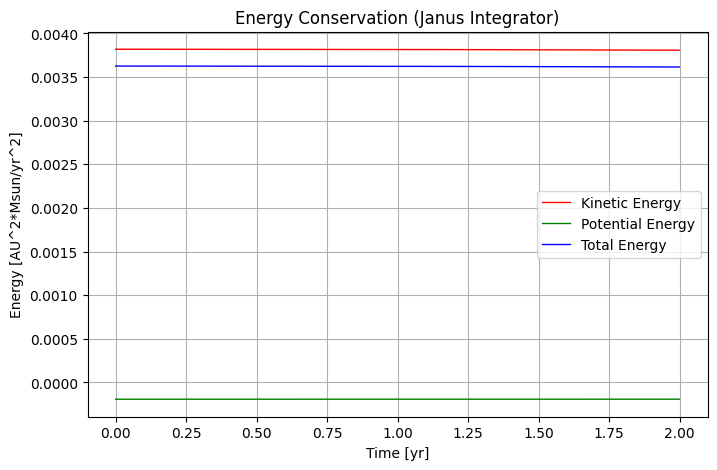

In [10]:
# Plot energy conservation
plt.figure(figsize=(8,5))
plt.plot(np.arange(N_steps)*sim.dt, kinetic_energy, label='Kinetic Energy', color='red', lw=1)
plt.plot(np.arange(N_steps)*sim.dt, potential_energy, label='Potential Energy', color='green', lw=1)
plt.plot(np.arange(N_steps)*sim.dt, total_energy, label='Total Energy', color='blue', lw=1)
plt.xlabel('Time [yr]')
plt.ylabel('Energy [AU^2*Msun/yr^2]')
plt.title('Energy Conservation (Janus Integrator)')
plt.grid(True)
plt.legend()
plt.show()

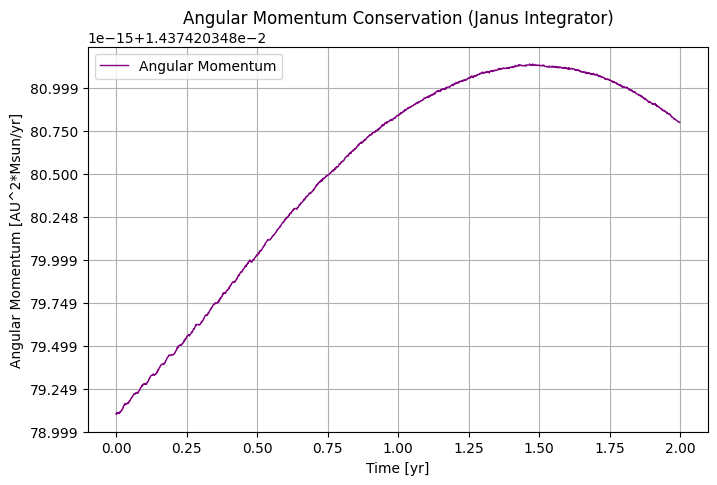

In [11]:
# Plot angular momentum conservation
plt.figure(figsize=(8,5))
plt.plot(np.arange(N_steps)*sim.dt, angular_momentum, label='Angular Momentum', color='purple', lw=1)
plt.xlabel('Time [yr]')
plt.ylabel('Angular Momentum [AU^2*Msun/yr]')
plt.title('Angular Momentum Conservation (Janus Integrator)')
plt.grid(True)
plt.legend()
plt.show()

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/03-LEAPFROG-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/05-MERCURIUS-Integrator.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-04-04.gif">